<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[ConvNeXt-Tiny] Epoch   1/100 | LR: 6.78e-05 | train loss 0.8362 acc 0.704 | val loss 0.5248 acc 0.786 *


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[ConvNeXt-Tiny] Epoch   2/100 | LR: 6.78e-05 | train loss 0.5565 acc 0.812 | val loss 0.5824 acc 0.809


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


...

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[ConvNeXt-Tiny] Epoch  12/100 | LR: 6.78e-05 | train loss 0.0224 acc 0.994 | val loss 0.4758 acc 0.877


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[ConvNeXt-Tiny] Epoch  13/100 | LR: 6.78e-05 | train loss 0.1220 acc 0.969 | val loss 0.5123 acc 0.839


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[ConvNeXt-Tiny] Epoch  14/100 | LR: 6.78e-05 | train loss 0.0417 acc 0.989 | val loss 0.5161 acc 0.859

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 14.

[ConvNeXt-T

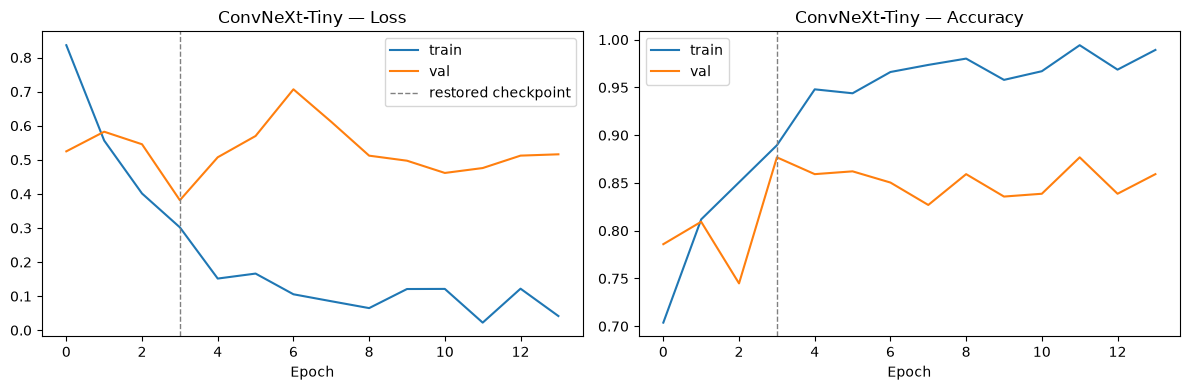

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[ConvNeXt-Tiny] Test accuracy: 0.837


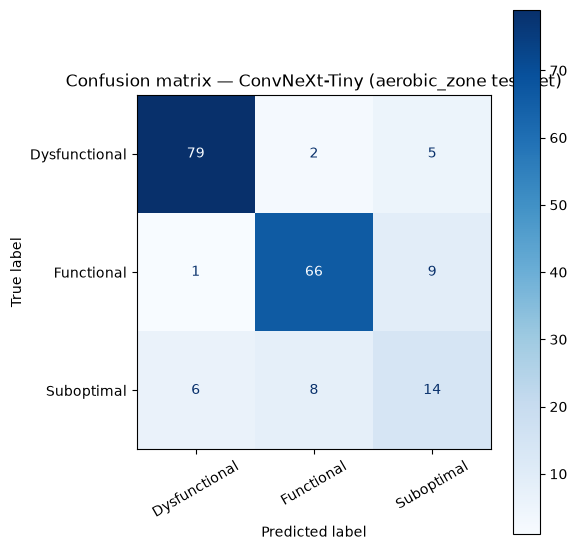

               precision    recall  f1-score   support

Dysfunctional      0.919     0.919     0.919        86
   Functional      0.868     0.868     0.868        76
   Suboptimal      0.500     0.500     0.500        28

     accuracy                          0.837       190
    macro avg      0.762     0.762     0.762       190
 weighted avg      0.837     0.837     0.837       190



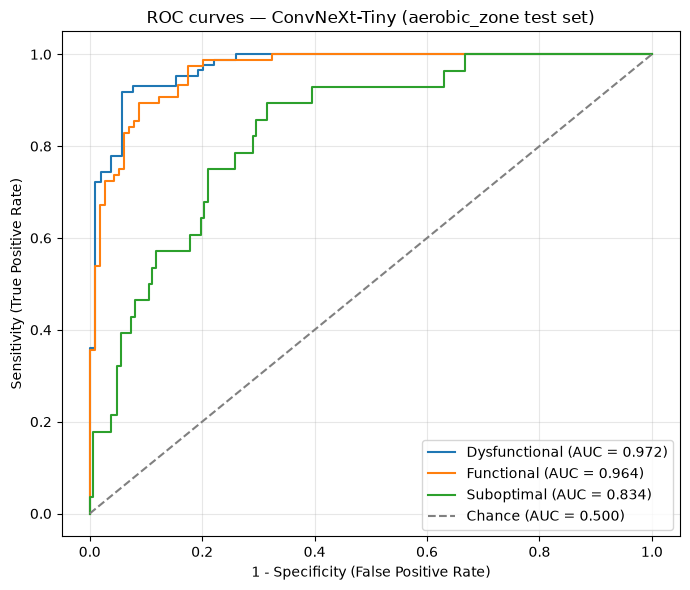

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.972
  Functional     : 0.964
  Suboptimal     : 0.834

Mean AUC (over 3/3 classes with test examples): 0.923


(np.float64(0.8368421052631579),
 {'Dysfunctional': 0.9720483005366727,
  'Functional': 0.9635272391505079,
  'Suboptimal': 0.8335537918871253})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/aerobic_zone_pad_noaug/results_aerobic_zone_convnext_tiny_stratified.pkl
Saved model weights to ../models/pad/aerobic_zone_convnext_tiny_cnn.pt
